In [37]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage, SystemMessage, ToolMessage
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
from pydantic import BaseModel
from tavily import TavilyClient
import os
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

_=load_dotenv()

In [38]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [39]:
model = ChatAnthropic(model_name='claude-haiku-4-5-20251001')

In [40]:
class Queries(BaseModel):
    queries: List[str]

In [41]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 
------
{content}"""

REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""

RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""

In [42]:
tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [43]:
def plan_node(state:AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    node_response = model.invoke(messages)
    return {'plan':node_response.content}

In [44]:
def research_node(state:AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        node_response = tavily.search(query = q, max_results = 2)
        for r in node_response['results']:
            content.append(r['content'])
    return {'content':content}

In [45]:
def generation_node(state:AgentState):
    content = '\n\n'.join(state['content'] or [])
    message = HumanMessage(content = f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(content = WRITER_PROMPT.format(content=content)),
        message
    ]
    node_response = model.invoke(messages)
    return {
        'draft': node_response.content,
        'revision_number': state.get('revision_number',1)+1
    }

In [46]:
def reflection_node(state:AgentState):
    messages = [
        SystemMessage(content = REFLECTION_PROMPT),
        HumanMessage(content = state['draft'])
    ]
    node_response = model.invoke(messages)
    return {'critique':node_response.content}

In [47]:
def research_critique_node(state:AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        node_response = tavily.search(query = q, max_results = 2)
        for r in node_response['results']:
            content.append(r['content'])
    return {'content':content}

In [48]:
def should_continue(state):
    if state['revision_number'] > state['max_revisions']:
        return END
    return 'reflect'

In [50]:
graph = StateGraph(AgentState)
graph.add_node('planner',plan_node)
graph.add_node('research_critique',research_critique_node)
graph.add_node('research_planner',research_node)
graph.add_node('reflect',reflection_node)
graph.add_node('generator',generation_node)
graph.add_conditional_edges('generator',should_continue,{'reflect':'reflect',END:END})
graph.add_edge('planner','research_planner')
graph.add_edge('research_planner','generator')
graph.add_edge('reflect','research_critique')
graph.add_edge('research_critique','generator')
graph.set_entry_point('planner')
graph = graph.compile(checkpointer=memory)

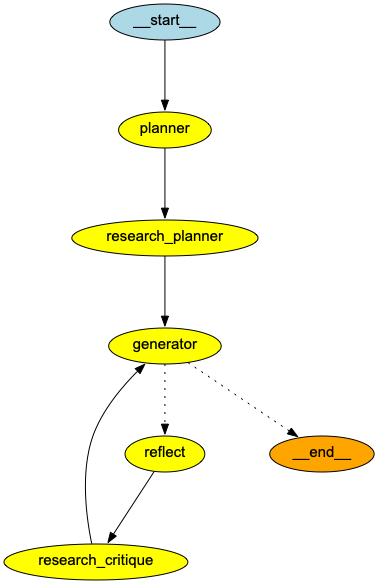

In [51]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [52]:
thread = {'configurable':{'thread_id':'1'}}
for s in graph.stream({
    'task':'the impact of reinforcement learning from human feedback on AI alignment.',
    'max_revisions':2,
    'revision_number':1,
    'content':[]
},thread):
    print(s)

{'planner': {'plan': "# The Impact of Reinforcement Learning from Human Feedback on AI Alignment\n\n## I. Introduction\n- **Hook**: The challenge of ensuring AI systems behave according to human values\n- **Background**: Define RLHF and the AI alignment problem\n- **Thesis Statement**: RLHF represents a significant but imperfect step toward alignment, offering practical benefits while introducing new challenges\n- *Note: Keep accessible to non-specialist readers; define technical terms clearly*\n\n## II. The AI Alignment Problem\n- **A. Core Definition**: What alignment means in AI context\n- **B. Why It Matters**: Existential and practical risks of misaligned systems\n- **C. Historical Context**: Evolution of alignment concerns\n- *Note: Establish why this problem warrants serious attention*\n\n## III. What is RLHF? Technical Overview\n- **A. Mechanism**: How RLHF works (reward modeling, training process)\n- **B. Distinction from Traditional RL**: Why human feedback differs from stand

In [53]:
final_state = graph.get_state(thread).values
print(final_state['revision_number'])
print(len(final_state['content']))
print(final_state['draft'])

3
12
# The Impact of Reinforcement Learning from Human Feedback on AI Alignment

## I. Introduction

As artificial intelligence systems grow increasingly sophisticated and integrated into critical domains—from healthcare to finance to national security—a fundamental question emerges: how can we ensure these systems behave in accordance with human values and intentions? This challenge, known as AI alignment, has moved from theoretical concern to pressing practical necessity. Reinforcement Learning from Human Feedback (RLHF) has emerged as the dominant industry approach to addressing this problem, powering the alignment efforts behind OpenAI's GPT-4, Anthropic's Claude, and Meta's Llama 2. Yet despite its widespread adoption and demonstrated improvements in model behavior, RLHF remains a fundamentally limited and imperfect tool. While RLHF represents a significant practical step toward ensuring AI systems are helpful, harmless, and honest, it should not be mistaken for a comprehensive so